In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [6]:
IMG_SIZE = 224
DATA_DIR = "Data" 

In [7]:
def load_dataset(data_dir=DATA_DIR, img_size=300, max_images_per_class=10):
    labels = []
    images = []
    classes = sorted(os.listdir(data_dir))
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}
    
    for cls_name in classes:
        cls_folder = os.path.join(data_dir, cls_name)
        if not os.path.isdir(cls_folder):
            continue
        count = 0
        for img_name in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            # Convertir la imagen a float32 y normalizarla
            img = img.astype(np.float32) / 255.0
            images.append(img)
            labels.append(class_to_idx[cls_name])
            count += 1
            if count >= max_images_per_class:
                break

    images = np.array(images)
    labels = np.array(labels)
    return images, labels, classes

# Carga del dataset limitado
images, labels, classes = load_dataset()
print("Número de imágenes:", len(images))
print("Clases:", classes)


Número de imágenes: 260
Clases: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


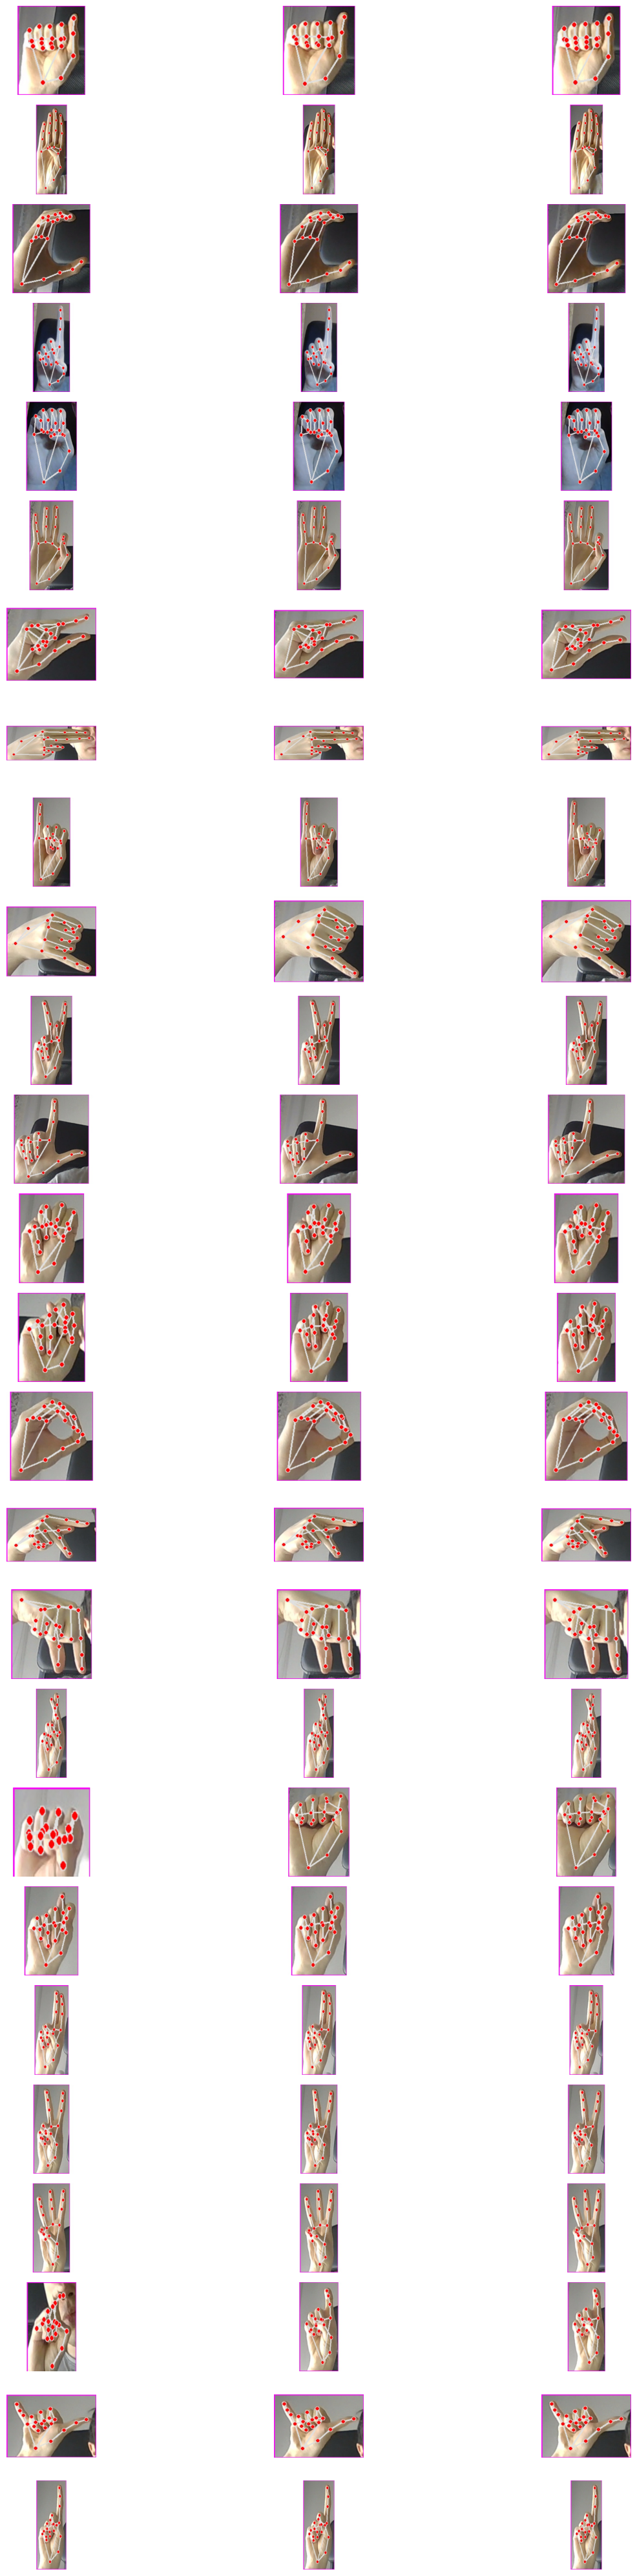

In [8]:
# Mostrar algunas imágenes de cada clase
num_samples = 3  # Número de imágenes a mostrar por clase

plt.figure(figsize=(15, 40))  # Ancho=15, Alto=40

for i, cls in enumerate(classes):
    cls_idx = i  # El índice asignado a la clase
    cls_images = images[labels == cls_idx]
    for j in range(min(num_samples, len(cls_images))):
        plt.subplot(len(classes), num_samples, i * num_samples + j + 1)
        plt.imshow(cv2.cvtColor(cls_images[j], cv2.COLOR_BGR2RGB))
        plt.axis('off')
        if j == 0:
            plt.ylabel(cls, fontsize=12)
plt.tight_layout()
plt.show()
